# Laboratorio #3

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab3)

## Análisis exploratorio

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from collections import Counter
from PIL import Image

### Constantes

In [28]:
BASE_DIR = "./data_original/train"
IMAGE_DIR = "./images"
REPORT_DIR = "./reports"
MODALITIES = ['m0', 'm1', 'm2', 'm3', 'm4']
DO_EA = False

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

reportPath = os.path.join(REPORT_DIR, "analisis_exploratorio.txt")

### Generación de reportes

In [29]:
def writeToReport(text, printAlso=True):
    with open(reportPath, "a", encoding="utf-8") as f:
        f.write(text + "\n")
    if printAlso:
        print(text)

In [30]:
def resetReport():
    with open(reportPath, "w", encoding="utf-8") as f:
        f.write("ANÁLISIS EXPLORATORIO DATASET IMAGENES\n\n")

In [31]:
def checkImageResolution(modality='m0'):
    path = os.path.join(BASE_DIR, modality)
    imgPath = os.path.join(path, random.choice(os.listdir(path)))
    img = Image.open(imgPath)
    size = img.size
    writeToReport(f"Ejemplo de resolución de imágen de {modality}: {size}")
    return size

In [32]:
def countDigitsPerModality():
    writeToReport("Distribución de imágenes de dígitos por modalidad:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        files = os.listdir(path)
        digits = [f.split('.')[-2] for f in files]
        count = Counter(digits)
        writeToReport(f"{modality}:")
        for d in sorted(count):
            writeToReport(f"  Dígito {d}: {count[d]} imágenes")
        writeToReport("")

In [33]:
def countImagesPerModality():
    writeToReport("Total de imágenes por modo:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        total = len(os.listdir(path))
        writeToReport(f"{modality}: {total} imágenes")
    writeToReport("")

In [34]:
def showDigitExamplesPerModality(digit="5", saveImage=False):
    plt.figure(figsize=(15, 6))
    for i, modality in enumerate(MODALITIES):
        modalityPath = os.path.join(BASE_DIR, modality)
        digitImages = [f for f in os.listdir(modalityPath) if f.endswith(f".{digit}.png")]
        if not digitImages:
            continue

        imgFile = random.choice(digitImages)
        imgPath = os.path.join(modalityPath, imgFile)
        img = mpimg.imread(imgPath)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{modality} - {digit}")
        plt.axis("off")

    plt.suptitle(f"Ejemplo del dígito '{digit}' en las modalidades")
    plt.tight_layout()

    if saveImage:
        savePath = os.path.join(IMAGE_DIR, f"digit_{digit}_modalities.png")
        plt.savefig(savePath)
        writeToReport(f"Image saved to: {savePath}")

    plt.show()

In [35]:
if DO_EA:
    resetReport()
    showDigitExamplesPerModality(digit="2", saveImage=True)
    checkImageResolution(modality="m0")
    countImagesPerModality()
    countDigitsPerModality()

## Avances

### Librerías

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from matplotlib.image import imread
import keras
from keras.utils import image_dataset_from_directory

In [65]:
numberToName = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine",
}

## Explorando los Datos

In [66]:
def showRandomExamples(folder="data/train", samples=9):
    """
    Muestra imágenes aleatorias de distintas clases desde la carpeta dada.
    """
    plt.figure(figsize=(12, 6))
    for i in range(samples):
        number = random.randint(0, 9)
        subfolder = numberToName[number]
        filename = f'{folder}/{subfolder}/m{random.randint(1,4)}-0.{number}.png'
        try:
            image = imread(filename)
            plt.subplot(3, 3, i + 1)
            plt.imshow(image, cmap="gray")
            plt.title(f"{subfolder}")
            plt.axis("off")
        except FileNotFoundError:
            print(f"Imagen no encontrada: {filename}")
    plt.tight_layout()
    plt.show()

In [67]:
def loadImageDataset(dataDir="data/train", batchSize=32, imageSize=(28, 28), shuffle=True):
    """
    Carga el dataset desde carpetas organizadas por clase usando Keras.
    Retorna un objeto tf.data.Dataset listo para entrenamiento.
    """
    dataset = image_dataset_from_directory(
        dataDir,
        labels='inferred',
        batch_size=batchSize,
        image_size=imageSize,
        shuffle=shuffle
    )
    return dataset

In [68]:
def loadImageDatasetWithSplit(dataDir="data/train", imageSize=(28, 28), batchSize=32, valSplit=0.2, seed=123):
    train_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="training",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    val_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="validation",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    return train_ds, val_ds

Esta función carga un conjunto de imágenes desde `data/train` y lo divide automáticamente en dos subconjuntos:

- trains_ds
- val_ds


| Parámetro   | Descripción                                                                                        |
| ----------- | -------------------------------------------------------------------------------------------------- |
| `dataDir`   | Ruta a la carpeta raíz donde están las imágenes organizadas por clase. Por defecto: `"data/train"` |
| `imageSize` | Tamaño al que se redimensionan todas las imágenes. Por defecto: `(28, 28)`                         |
| `batchSize` | Cantidad de imágenes que se agrupan en un lote. Por defecto: `32`                                  |
| `valSplit`  | Porcentaje del conjunto que se reservará como validación. Por defecto: `0.2` (20%)                 |
| `seed`      | Semilla aleatoria que asegura que la división sea reproducible.                                    |

In [69]:
def normalizeDataset(dataset):
    normalization_layer = Rescaling(1./255)
    return dataset.map(lambda x, y: (normalization_layer(x), y))

In [41]:
# showRandomExamples()

Como se puede ver las imágenes tienen una gran variedad de fondos, pero en tamaño son todas iguales por lo que no hay que aplicarles transformaciones de resolución.

## Entrenamiento

### Librerias

In [71]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
from tensorflow.keras.layers import Rescaling

### Constantes

In [72]:
train_ds, val_ds = loadImageDatasetWithSplit()
train_ds = normalizeDataset(train_ds)
val_ds = normalizeDataset(val_ds)

Found 300000 files belonging to 10 classes.
Using 240000 files for training.
Found 300000 files belonging to 10 classes.
Using 60000 files for validation.


### Módelos

In [73]:
def buildSimpleCNN(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

Esto crea un modelo **de red neuronal convolucional (CNN)** simple:

* `Conv2D`: una capa convolucional que extrae características como bordes y formas locales.
* `MaxPooling2D`: reduce la resolución manteniendo la información importante.
* `Flatten`: convierte la matriz en un vector para pasarla a la red densa.
* `Dense`: capas densas (fully connected) que aprenden relaciones entre las características extraídas.
* `softmax`: convierte la salida en probabilidades sobre 10 clases (números del 0 al 9).

In [74]:
def buildVggStyleCNN(inputShape=(28, 28, 3), numClasses=10, dropoutRate=0.25):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [75]:
def buildSimpleDenseModel(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Flatten(input_shape=inputShape),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [76]:
def trainAndEvaluate(model, trainData, valData, epochs=5, modelName="Model"):
    history = model.fit(trainData, validation_data=valData, epochs=epochs, verbose=1)
    loss, acc = model.evaluate(valData, verbose=0)
    print(f"{modelName} Accuracy: {acc*100:.2f}%")

    # Graficar
    plt.figure(figsize=(12, 4))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Exactitud
    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle(modelName)
    plt.tight_layout()
    plt.show()

    return acc

### Hiperparámetros

In [77]:
epochs = 5
dropoutOptions = [0.2, 0.3]

### Ejecutando modelos

In [78]:
results = []

Epoch 1/5


7500/7500 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - accuracy: 0.9091 - loss: 0.2970 - val_accuracy: 0.9346 - val_loss: 0.2121
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.9550 - loss: 0.1450 - val_accuracy: 0.9584 - val_loss: 0.1355
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.9651 - loss: 0.1090 - val_accuracy: 0.9592 - val_loss: 0.1368
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.9721 - loss: 0.0865 - val_accuracy: 0.9621 - val_loss: 0.1312
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - accuracy: 0.9764 - loss: 0.0709 - val_accuracy: 0.9620 - val_loss: 0.1375
Simple CNN Accuracy: 96.20%


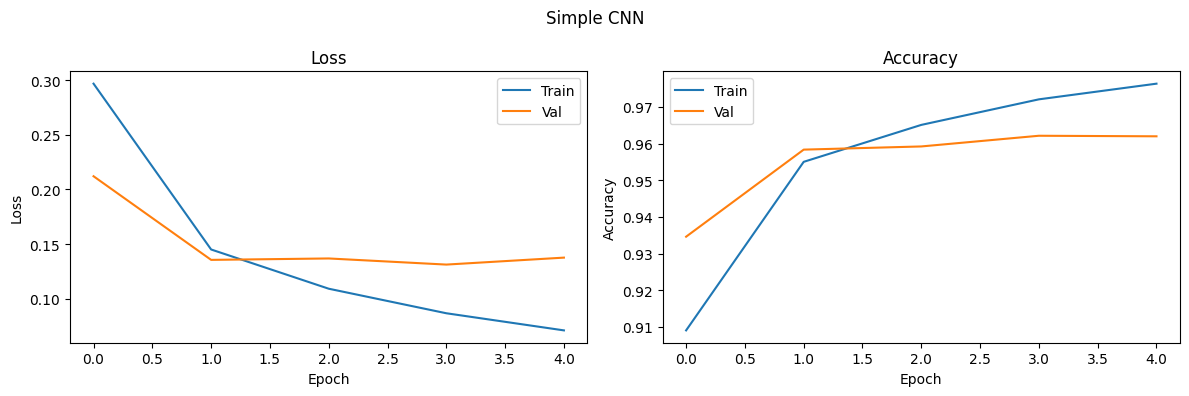

In [79]:
# CNN
model1 = buildSimpleCNN()
acc1 = trainAndEvaluate(model1, train_ds, val_ds, epochs=epochs, modelName="Simple CNN")
results.append(("Simple CNN", acc1))

| Aspecto       | Resultado                                                                  |
| ------------- | -------------------------------------------------------------------------- |
| Entrenamiento | Aprende rápidamente y sigue mejorando                                      |
| Validación    | Mejora al inicio, luego se estabiliza                                      |
| Sobreajuste   | Comienza a aparecer levemente después del epoch 3-4                        |

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.9185 - loss: 0.2540 - val_accuracy: 0.9683 - val_loss: 0.1049
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - accuracy: 0.9658 - loss: 0.1081 - val_accuracy: 0.9788 - val_loss: 0.0662
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - accuracy: 0.9727 - loss: 0.0843 - val_accuracy: 0.9811 - val_loss: 0.0576
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - accuracy: 0.9762 - loss: 0.0724 - val_accuracy: 0.9794 - val_loss: 0.0627
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - accuracy: 0.9787 - loss: 0.0649 - val_accuracy: 0.9844 - val_loss: 0.0502
VGG Style CNN (Dropout=0.2) Accuracy: 98.44%


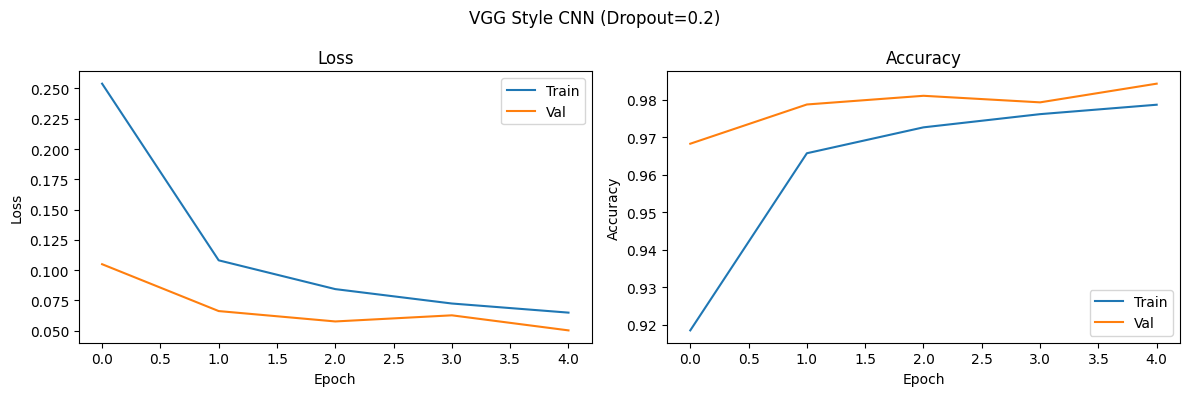

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.9065 - loss: 0.2903 - val_accuracy: 0.9700 - val_loss: 0.0943
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - accuracy: 0.9556 - loss: 0.1365 - val_accuracy: 0.9783 - val_loss: 0.0706
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.9645 - loss: 0.1087 - val_accuracy: 0.9788 - val_loss: 0.0678
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - accuracy: 0.9681 - loss: 0.0979 - val_accuracy: 0.9794 - val_loss: 0.0659
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - accuracy: 0.9710 - loss: 0.0881 - val_accuracy: 0.9829 - val_loss: 0.0551
VGG Style CNN (Dropout=0.3) Accuracy: 98.29%


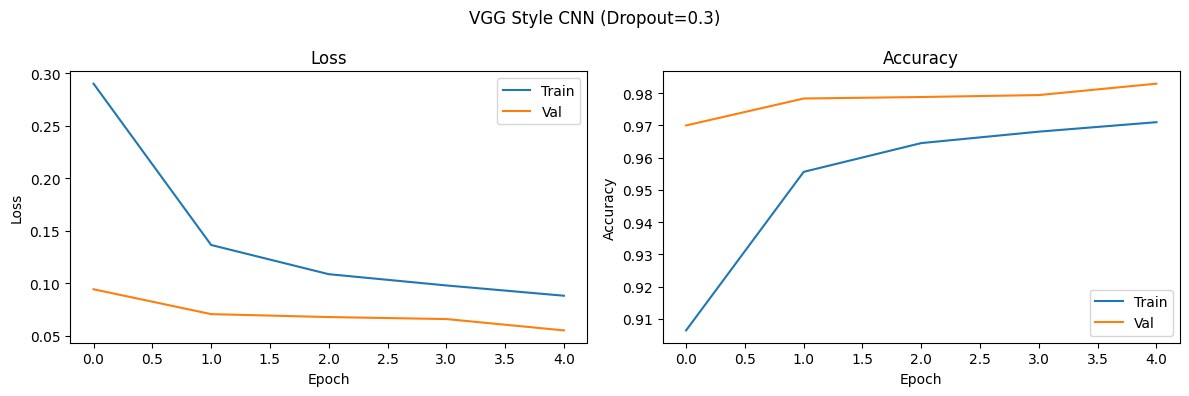

In [ ]:
# VGG style con tuning
for dropout in dropoutOptions:
    modelName = f"VGG Style CNN (Dropout={dropout})"
    model2 = buildVggStyleCNN(dropoutRate=dropout)
    acc2 = trainAndEvaluate(model2, train_ds, val_ds, epochs=epochs, modelName=modelName)
    results.append((modelName, acc2))

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - accuracy: 0.6745 - loss: 0.9866 - val_accuracy: 0.7357 - val_loss: 0.8193
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.7736 - loss: 0.7001 - val_accuracy: 0.7809 - val_loss: 0.6762
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.7985 - loss: 0.6240 - val_accuracy: 0.8075 - val_loss: 0.6015
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.8136 - loss: 0.5781 - val_accuracy: 0.8084 - val_loss: 0.5993
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.8234 - loss: 0.5457 - val_accuracy: 0.7912 - val_loss: 0.6580
Simple Dense NN Accuracy: 79.12%


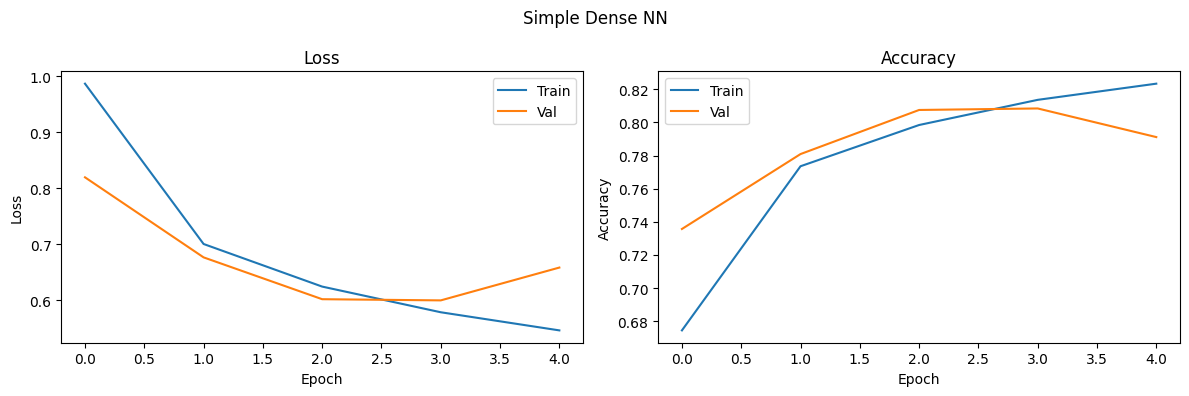

In [81]:
# DL simple
model3 = buildSimpleDenseModel()
acc3 = trainAndEvaluate(model3, train_ds, val_ds, epochs=epochs, modelName="Simple Dense NN")
results.append(("Simple Dense NN", acc3))

In [83]:
print("--- Resumen resultados ---")
for name, acc in results:
    print(f"{name}: {acc*100:.2f}%")

bestModel = max(results, key=lambda x: x[1])
print(f"\nMejor modelo: {bestModel[0]} con precisión {bestModel[1]*100:.2f}%")

--- Resumen resultados ---
Simple CNN: 96.20%
VGG Style CNN (Dropout=0.2): 98.44%
VGG Style CNN (Dropout=0.3): 98.29%
Simple Dense NN: 79.12%

Mejor modelo: VGG Style CNN (Dropout=0.2) con precisión 98.44%
